In [1]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler  

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


import mlflow
import yaml
import joblib
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from dotenv import load_dotenv

load_dotenv()

2026-04-24 18:45:35.357118: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-24 18:45:35.552670: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-24 18:45:35.552715: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-24 18:45:35.587099: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-24 18:45:35.658483: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-24 18:45:35.659989: I tensorflow/core/platform/cpu_feature_guard.cc:1

True

In [2]:
BASE_DIR = Path("..").resolve()

spark = (
    SparkSession.builder.master("local[*]").appName("SerumQA-anomaly-detection").config(
    "spark.jars", str(BASE_DIR / "drivers" / "postgresql-42.7.3.jar")).config(
    "spark.driver.extraClassPath", str(BASE_DIR / "drivers" / "postgresql-42.7.3.jar")).config(
    "spark.sql.shuffle.partitions", "8").getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version :", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/24 18:45:42 WARN Utils: Your hostname, LC-016, resolves to a loopback address: 127.0.1.1; using 192.168.2.101 instead (on interface wlp3s0)
26/04/24 18:45:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/04/24 18:45:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark version : 4.1.1


In [3]:
CONFIG_PATH = BASE_DIR / "configs" / "config.yaml"

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

In [4]:
jdbc_url = (
    f"jdbc:postgresql://"
    f"{os.getenv('POSTGRES_HOST', 'localhost')}:"
    f"{os.getenv('POSTGRES_PORT', '5433')}/"
    f"{os.getenv('POSTGRES_DB')}"
)

properties = {
    "user": os.getenv("POSTGRES_USER"),
    "password": os.getenv("POSTGRES_PASSWORD"),
    "driver": "org.postgresql.Driver"
}

print("JDBC URL:", jdbc_url)
print("Contamination:", config['anomaly_detection']['contamination'])

JDBC URL: jdbc:postgresql://localhost:5433/serum_mlmodels
Contamination: 0.01


In [5]:
gold_sdf = spark.read.jdbc(jdbc_url, "gold.qa_features", properties=properties)

print(f"Gold Rows: {gold_sdf.count():,}")

Gold Rows: 431,068


In [6]:
df = gold_sdf.toPandas()
print(df.shape)
df.head()

(431068, 18)


,id,timestamp,system,event_type,severity,is_anomaly,deviation_count_7d,deviation_count_30d,anomaly_count_7d,anomaly_count_30d,oos_count_7d,oos_count_30d,critical_ratio_7d,critical_ratio_30d,anomaly_rate_7d,anomaly_rate_30d,deviation_count_7d,deviation_count_30d
0,1513,2020-05-15 11:28:27,Capping,capa,Minor,0,1,1,0,0,0,0,0.0,0.0,0.0,0.0,0,0
1,1500,2020-05-15 15:30:32,Capping,capa,Minor,0,2,2,0,0,0,0,0.0,0.0,0.0,0.0,0,0
2,1494,2020-05-15 17:13:42,Capping,capa,Critical,0,3,3,0,0,0,0,0.0,0.0,0.0,0.0,0,0
3,2633,2020-05-16 16:19:22,Capping,capa,Minor,0,4,4,0,0,0,0,0.0,0.0,0.0,0.0,0,0
4,1544,2020-05-17 19:52:13,Capping,capa,Minor,0,5,5,0,0,0,0,0.0,0.0,0.0,0.0,0,0


In [7]:
NUMERIC_COLS = [
    "deviation_count_7d", "deviation_count_30d",
    "complaint_rate_7d", "capa_overdue_ratio_30d",
    "oos_count_7d", "unusual_event_count_7d",
    "material_complaint_count_7d", "quality_risk_open_7d",
    "critical_ratio_7d", "major_ratio_7d",
]

CAT_COLS = ["system", "severity", "event_type"]

In [8]:
df_encoded = df[NUMERIC_COLS + ["timestamp", "is_anomaly"]].copy()

print("Encoded shape:", df_encoded.shape)
print(df_encoded.columns.tolist())

Encoded shape: (431068, 35)
['deviation_count_7d', 'deviation_count_30d', 'anomaly_count_7d', 'anomaly_count_30d', 'deviation_count_7d', 'deviation_count_30d', 'anomaly_rate_7d', 'anomaly_rate_30d', 'oos_count_7d', 'oos_count_30d', 'critical_ratio_7d', 'critical_ratio_30d', 'timestamp', 'is_anomaly', 'system_Blending', 'system_Capping', 'system_Documentation', 'system_Filling', 'system_Lyophilization', 'system_Manufacturing', 'system_QC Lab', 'system_Unknown', 'system_Warehouse', 'severity_Critical', 'severity_Major', 'severity_Minor', 'event_type_ade', 'event_type_capa', 'event_type_change_control', 'event_type_complaint', 'event_type_critical_alarm', 'event_type_deviation', 'event_type_media_fill', 'event_type_oos', 'event_type_vendor_audit']


In [9]:
df_encoded["timestamp"] = pd.to_datetime(df_encoded["timestamp"])
SPLIT_DATE = "2024-01-01"

train_df = df_encoded[df_encoded["timestamp"] < SPLIT_DATE]
test_df = df_encoded[df_encoded["timestamp"] >= SPLIT_DATE]

print(f" Train: {len(train_df):,} | Test: {len(test_df):,}")
print(f"Train anomaly rate: {train_df['is_anomaly'].mean():.4%}")
print(f"Test anomaly rate: {test_df['is_anomaly'].mean():.4%}")

 Train: 340,976 | Test: 90,092
Train anomaly rate: 0.4625%
Test anomaly rate: 0.4762%


In [10]:
feature_cols = [c for c in df_encoded.columns if c not in ["timestamp", "is_anomaly"]]

X_train = train_df[feature_cols].values
y_train = train_df["is_anomaly"].values
X_test = test_df[feature_cols].values
y_test = test_df["is_anomaly"].values

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f" feature count Train: {X_train.shape}")
print(f"feature count Test: {X_test.shape}")



 feature count Train: (340976, 33)
feature count Test: (90092, 33)


In [12]:
contamination = config['anomaly_detection']['contamination']
iso_forest = IsolationForest(n_estimators=100, contamination=contamination, random_state=42, n_jobs=-1)


In [13]:
iso_forest.fit(X_train)

,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [14]:
if_raw = iso_forest.predict(X_test)
if_preds = (if_raw == -1).astype(int)
print(f"Predicted Anomalies: {if_preds.sum():,} / {len(if_preds):,}")

Predicted Anomalies: 447 / 90,092


In [15]:
print("=== Isolation Forest ===")
print(classification_report(y_test, if_preds, target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC: {roc_auc_score(y_test, if_preds):.4f}")

=== Isolation Forest ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     89663
     Anomaly       0.68      0.71      0.69       429

    accuracy                           1.00     90092
   macro avg       0.84      0.85      0.85     90092
weighted avg       1.00      1.00      1.00     90092

ROC-AUC: 0.8535


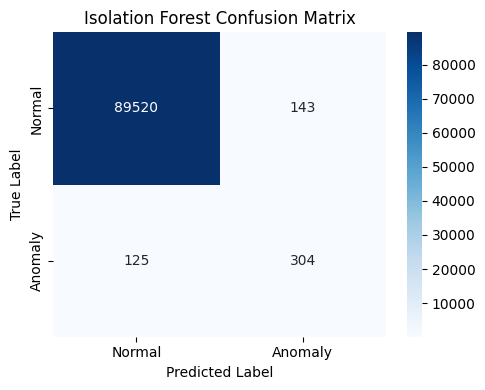

In [16]:
cm = confusion_matrix(y_test, if_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title("Isolation Forest Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [17]:
X_train_normal = X_train[y_train == 0]
print(f"Training autoencoder on {len(X_train_normal):,} normal rows")

Training autoencoder on 339,399 normal rows


In [18]:
input_dim = X_train.shape[1]
print("Input dimension:", input_dim)

Input dimension: 33


In [19]:
autoencoder = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(input_dim, activation='linear')
])


In [20]:
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                2176      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 32)                544       
                                                                 
 dense_4 (Dense)             (None, 64)                2112      
                                                                 
 dense_5 (Dense)             (None, 33)                2145      
                                                                 
Total params: 9585 (37.44 KB)
Trainable params: 9585 (37

In [21]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

2026-04-24 18:46:20.067997: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 40320588 exceeds 10% of free system memory.


Epoch 1/50


2026-04-24 18:46:20.469479: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 40320588 exceeds 10% of free system memory.


1194/1194 [==============================] - 3s 2ms/step - loss: 0.0686 - val_loss: 1.7852
Epoch 2/50
1194/1194 [==============================] - 3s 3ms/step - loss: 0.0110 - val_loss: 1.6457
Epoch 3/50
1194/1194 [==============================] - 3s 3ms/step - loss: 0.0072 - val_loss: 1.5453
Epoch 4/50
1194/1194 [==============================] - 3s 3ms/step - loss: 0.0052 - val_loss: 1.5632
Epoch 5/50
1194/1194 [==============================] - 3s 3ms/step - loss: 0.0039 - val_loss: 1.5906
Epoch 6/50
1194/1194 [==============================] - 3s 3ms/step - loss: 0.0032 - val_loss: 1.5611
Epoch 7/50
1194/1194 [==============================] - 3s 3ms/step - loss: 0.0024 - val_loss: 1.5721
Epoch 8/50
1194/1194 [==============================] - 3s 3ms/step - loss: 0.0020 - val_loss: 1.5314
Epoch 9/50
1194/1194 [==============================] - 3s 3ms/step - loss: 0.0019 - val_loss: 1.5458
Epoch 10/50
1194/1194 [==============================] - 3s 3ms/step - loss: 0.0017 - val_los

In [22]:
train_recon = autoencoder.predict(X_train_normal)
train_mse = np.mean(np.power(X_train_normal - train_recon, 2), axis=1)
threshold = np.mean(train_mse) + 2 * np.std(train_mse)
print(f"Reconstruction error threshold: {threshold:.6f}")

    1/10607 [..............................] - ETA: 24:44

2026-04-24 18:48:06.952844: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 44800668 exceeds 10% of free system memory.


10607/10607 [==============================] - 19s 2ms/step


2026-04-24 18:48:29.533858: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 44800668 exceeds 10% of free system memory.


Reconstruction error threshold: 1.421704


In [23]:
test_recon = autoencoder.predict(X_test)
test_mse = np.mean(np.power(X_test - test_recon, 2), axis=1)
ae_preds = (test_mse > threshold).astype(int)

print("\n=== Autoencoder ===")
print(classification_report(y_test, ae_preds, target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC: {roc_auc_score(y_test, ae_preds):.4f}")

2816/2816 [==============================] - 3s 1ms/step

=== Autoencoder ===
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97     89663
     Anomaly       0.02      0.23      0.03       429

    accuracy                           0.94     90092
   macro avg       0.51      0.59      0.50     90092
weighted avg       0.99      0.94      0.96     90092

ROC-AUC: 0.5858


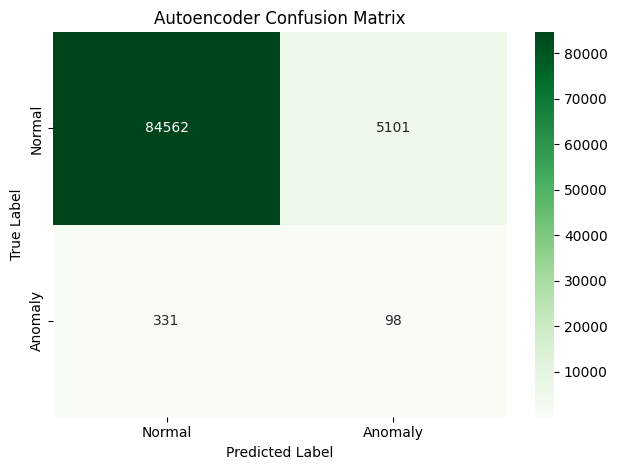

In [24]:
cm_ae = confusion_matrix(y_test, ae_preds)
plt.Figure(figsize=(5,4))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Greens',xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.title("Autoencoder Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

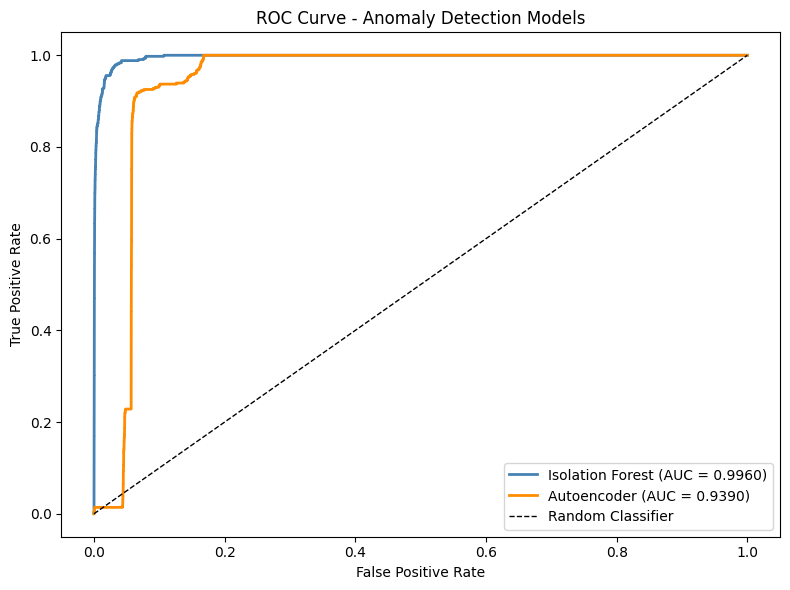

Isolation Forest AUC: 0.9960
Autoencoder AUC: 0.9390


In [25]:
if_scores = -iso_forest.decision_function(X_test)
ae_scores = test_mse

fpr_if, tpr_if, _ = roc_curve(y_test, if_scores)
fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_scores)

auc_if = auc(fpr_if, tpr_if)
auc_ae = auc(fpr_ae, tpr_ae)

plt.figure(figsize=(8,6))
plt.plot(fpr_if, tpr_if, label=f"Isolation Forest (AUC = {auc_if:.4f})", color='steelblue', lw=2)
plt.plot(fpr_ae, tpr_ae, label=f"Autoencoder (AUC = {auc_ae:.4f})", color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Anomaly Detection Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Isolation Forest AUC: {auc_if:.4f}")
print(f"Autoencoder AUC: {auc_ae:.4f}")

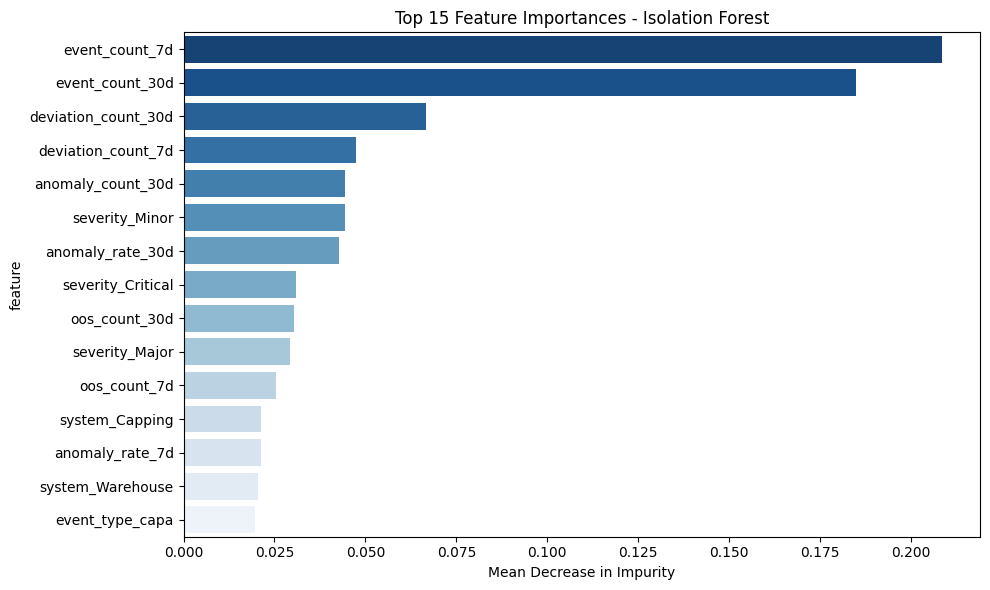

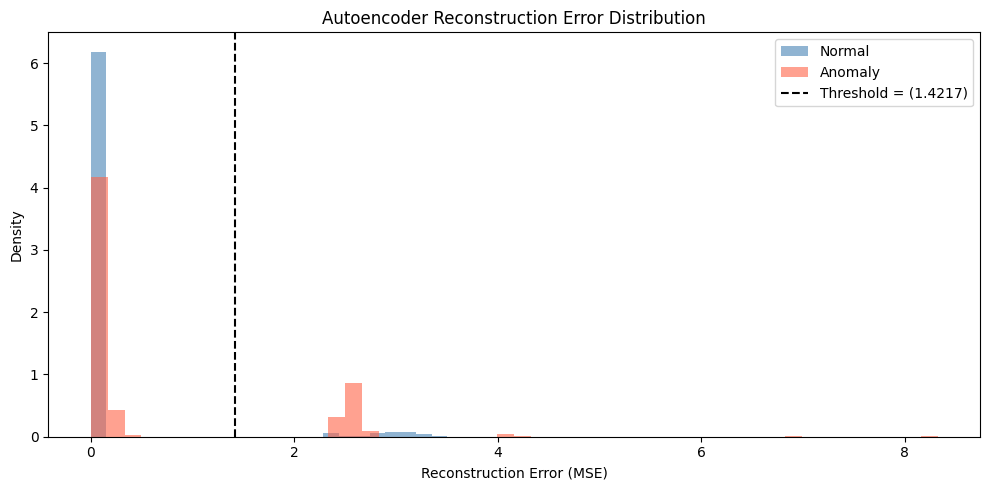

In [26]:
importances = np.mean([tree.feature_importances_ for tree in iso_forest.estimators_], axis=0)

feature_imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_imp_df,x="importance", y="feature", palette="Blues_r")
plt.title("Top 15 Feature Importances - Isolation Forest")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

# AE reconstruction error distribution — normal vs anomaly 
normal_errors = test_mse[y_test == 0]
anomaly_errors = test_mse[y_test == 1]

plt.figure(figsize=(10, 5))
plt.hist(normal_errors, bins=50, alpha=0.6, label='Normal', color='steelblue', density=True)
plt.hist(anomaly_errors, bins=50, alpha=0.6, label='Anomaly', color='tomato', density=True)
plt.axvline(threshold, color='black', linestyle='--', label=f"Threshold = ({threshold:.4f})")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")
plt.title("Autoencoder Reconstruction Error Distribution")
plt.legend()
plt.tight_layout()
plt.show()

### MLFlow Logging

In [27]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Serum-anomaly-detection")

with mlflow.start_run(run_name="Isolation-Forest"):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("contamination", contamination)
    report_if = classification_report(y_test, if_preds, target_names=["Normal", "Anomaly"], output_dict=True)
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, if_preds))
    mlflow.log_metric("precision_anomaly", report_if["Anomaly"]["precision"])
    mlflow.log_metric("recall_anomaly", report_if["Anomaly"]["recall"])
    mlflow.log_metric("f1_anomaly", report_if["Anomaly"]["f1-score"])
    mlflow.sklearn.log_model(iso_forest, "isolation_forest")
    print("IF logged.")

2026/04/24 18:48:39 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/04/24 18:48:39 INFO mlflow.tracking._tracking_service.client: 🏃 View run Isolation-Forest at: http://localhost:5000/#/experiments/3/runs/69a517562c174ad99c00e0dd44a07c83.
2026/04/24 18:48:39 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/3.


IF logged.


In [28]:
with mlflow.start_run(run_name="Autoencoder"):
    mlflow.log_param("architecture", "64-32-16-32-64")
    mlflow.log_param("threshold", float(threshold))
    report_ae = classification_report(y_test, ae_preds, target_names=["Normal", "Anomaly"], output_dict=True)
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, ae_preds))
    mlflow.log_metric("precision_anomaly", report_ae["Anomaly"]["precision"])
    mlflow.log_metric("recall_anomaly", report_ae["Anomaly"]["recall"])
    mlflow.log_metric("f1_anomaly", report_ae["Anomaly"]["f1-score"])
    mlflow.keras.log_model(autoencoder, "autoencoder")
    print("Autoencoder logged.")

2026/04/24 18:48:39 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: /tmp/tmp_qzv0q9t/model/data/model/assets


INFO:tensorflow:Assets written to: /tmp/tmp_qzv0q9t/model/data/model/assets
2026/04/24 18:48:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/04/24 18:48:45 INFO mlflow.tracking._tracking_service.client: 🏃 View run Autoencoder at: http://localhost:5000/#/experiments/3/runs/b82d6e3ab297498598af824ee33cd592.
2026/04/24 18:48:45 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://localhost:5000/#/experiments/3.


Autoencoder logged.


In [29]:
MODELS_DIR = BASE_DIR / "models"

MODELS_DIR.mkdir(exist_ok=True)


In [ ]:
joblib.dump(iso_forest, MODELS_DIR / "isolation_forest.pkl")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")
autoencoder.save(MODELS_DIR / "autoencoder.h5")

print("Saved:")
print(f"  {MODELS_DIR / 'isolation_forest.pkl'}")
print(f"  {MODELS_DIR / 'scaler.pkl'}")
print(f"  {MODELS_DIR / 'autoencoder.h5'}")

Saved:
  /home/rushikesh/Music/models/isolation_forest.pkl
  /home/rushikesh/Music/models/scaler.pkl
  /home/rushikesh/Music/models/autoencoder.h5


26/04/26 12:03:51 WARN TransportChannelHandler: Exception in connection from doclink.com/192.168.2.101:34327
io.netty.channel.unix.Errors$NativeIoException: recvAddress(..) failed with error(-110): Connection timed out
